1. Setup Awal

In [5]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum
import numpy as np
import os

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

 2. Konsep Large Margin Classification (Klasifikasi Margin Besar)


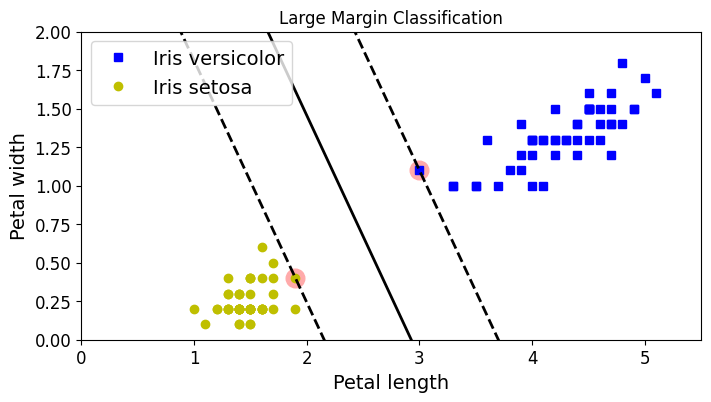

In [6]:
from sklearn.svm import SVC
from sklearn import datasets

# Memuat dataset iris
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

# Fokus pada 2 kelas saja: Setosa vs Versicolor
setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# Melatih model SVM
svm_clf = SVC(kernel="linear", C=float("inf"))
svm_clf.fit(X, y)

# Membuat plot untuk memvisualisasikan margin
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]
    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

plt.figure(figsize=(8,4))
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 5.5, 0, 2])
plt.title("Large Margin Classification")
plt.show()

3. Klasifikasi SVM Linier (Soft Margin Classification)

In [7]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # Iris virginica

# Membuat pipeline untuk scaling dan klasifikasi SVM
svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42)),
    ])

svm_clf.fit(X, y)

# Melakukan prediksi
print("Prediksi untuk petal length=5.5, petal width=1.7 :", svm_clf.predict([[5.5, 1.7]]))

Prediksi untuk petal length=5.5, petal width=1.7 : [1.]


4. Klasifikasi SVM Non-Linier (Polynomial Kernel)

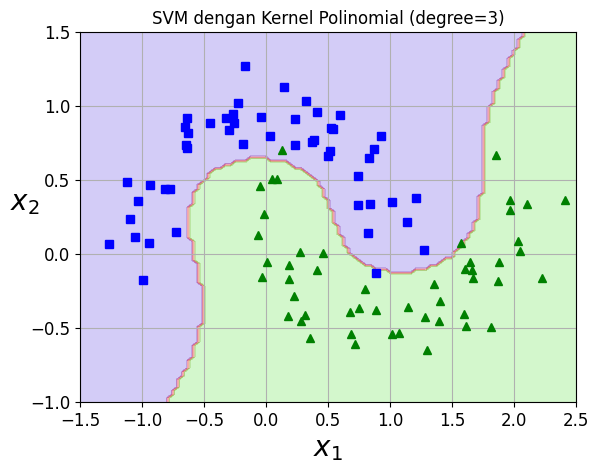

In [8]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np

# Membuat dataset non-linear (berbentuk bulan sabit)
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# Membuat pipeline yang menambahkan fitur polinomial lalu melatih SVM
polynomial_svm_clf = Pipeline([
        ("poly_features", PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
        # TAMBAHAN: max_iter dinaikkan untuk menghilangkan ConvergenceWarning
        ("svm_clf", LinearSVC(C=10, loss="hinge", random_state=42, max_iter=10000))
    ])

polynomial_svm_clf.fit(X, y)

# Fungsi untuk plot dataset dan decision boundary
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True) # PERBAIKAN: 'which' dihapus
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

# Plotting
plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("SVM dengan Kernel Polinomial (degree=3)")
plt.show()

5. Klasifikasi SVM Non-Linier (Gaussian RBF Kernel)

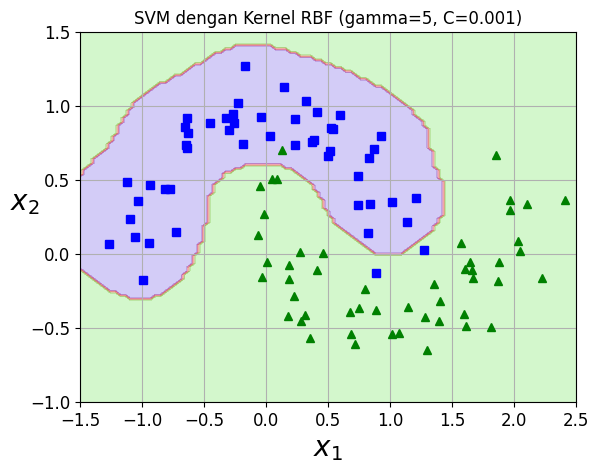

In [9]:
from sklearn.svm import SVC

# Melatih SVM dengan kernel RBF
# Gamma dan C adalah hyperparameter penting
rbf_kernel_svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="rbf", gamma=5, C=0.001))
    ])
rbf_kernel_svm_clf.fit(X, y)

# Plot hasil
plot_predictions(rbf_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("SVM dengan Kernel RBF (gamma=5, C=0.001)")
plt.show()

6. Regresi SVM

In [10]:
from sklearn.svm import LinearSVR, SVR

# Membuat data linear acak untuk regresi
np.random.seed(42)
m = 50
X = 2 * np.random.rand(m, 1)
y = (4 + 3 * X + np.random.randn(m, 1)).ravel()

# 1. Menggunakan LinearSVR
svm_reg = LinearSVR(epsilon=1.5, random_state=42)
svm_reg.fit(X, y)

# 2. Menggunakan SVR dengan kernel polinomial untuk data non-linear
m = 100
X = 2 * np.random.rand(m, 1) - 1
y = (0.2 + 0.1 * X + 0.5 * X**2 + np.random.randn(m, 1)/10).ravel()

svm_poly_reg = SVR(kernel="poly", degree=2, C=100, epsilon=0.1, gamma="scale")
svm_poly_reg.fit(X, y)

print("Model Regresi SVM selesai dilatih.")

Model Regresi SVM selesai dilatih.


Penjelasan Kode
Bagian 1. Setup Awal: Bagian ini melakukan persiapan standar library yang akan digunakan dalam chapter ini.

Bagian 2. Konsep Large Margin Classification: Ini adalah bagian konseptual untuk memahami ide utama di balik SVM. SVM tidak hanya mencari garis yang bisa memisahkan dua kelas, tetapi mencari garis pemisah terbaik. Garis terbaik didefinisikan sebagai garis yang memiliki margin (jarak) paling lebar ke titik data terdekat dari kedua kelas. Titik-titik data yang berada persis di tepi margin ini disebut Support Vectors, karena mereka yang "mendukung" atau menentukan posisi dari garis pemisah.

Bagian 3. Klasifikasi SVM Linier: Bagian ini menerapkan SVM pada data yang bisa dipisahkan secara linier (menggunakan garis lurus).

LinearSVC: Ini adalah implementasi SVM yang dioptimalkan untuk data linier.

StandardScaler: SVM sangat sensitif terhadap skala fitur. Jika satu fitur memiliki rentang nilai yang jauh lebih besar dari yang lain (misal, 0-1000 vs 0-1), SVM akan lebih condong ke fitur tersebut. StandardScaler digunakan untuk menormalkan skala semua fitur agar memiliki rata-rata 0 dan varians 1.

C: Ini adalah hyperparameter regularisasi. Nilai C yang kecil akan menciptakan margin yang lebih lebar tapi mungkin mengorbankan beberapa titik data (membiarkan ada yang salah klasifikasi). Nilai C yang besar akan menciptakan margin yang lebih sempit untuk mencoba mengklasifikasikan semua titik dengan benar, yang bisa berisiko overfitting. Ini disebut Soft Margin.

Bagian 4. Klasifikasi SVM Non-Linier (Polynomial Kernel): Digunakan ketika data tidak bisa dipisahkan dengan garis lurus. Tekniknya adalah dengan menambahkan fitur baru yang merupakan kombinasi polinomial dari fitur yang ada. PolynomialFeatures(degree=3) akan membuat fitur x_1
2
 ,x_2
2
 ,x_1x_2, dst. Dengan fitur-fitur baru ini, data yang tadinya tidak linier menjadi bisa dipisahkan secara linier di dimensi yang lebih tinggi. SVC(kernel="poly") adalah cara Scikit-Learn untuk melakukan trik ini secara efisien tanpa harus benar-benar membuat fitur baru secara manual.

Bagian 5. Klasifikasi SVM Non-Linier (Gaussian RBF Kernel): Ini adalah kernel lain yang sangat populer dan kuat. kernel="rbf" bekerja dengan menambahkan fitur berdasarkan fungsi kemiripan (similarity) terhadap beberapa titik data acuan (landmarks).

gamma: Hyperparameter ini mengontrol seberapa "lebar" pengaruh dari setiap titik data. gamma yang kecil membuat kurva pengaruh lebih landai dan lebar (model lebih simpel), sedangkan gamma yang besar membuat kurva pengaruh lebih tajam dan sempit (model lebih kompleks dan bisa overfitting).

Bagian 6. Regresi SVM: SVM juga bisa digunakan untuk tugas regresi (memprediksi nilai numerik). Tujuannya berkebalikan dengan klasifikasi. Jika klasifikasi SVM mencoba mencari "jalan" kosong selebar mungkin di antara data, maka regresi SVM mencoba mencari "jalan" yang bisa memuat sebanyak mungkin titik data di dalamnya.

epsilon (ε): Hyperparameter ini menentukan lebar "jalan" tersebut. Selama titik data berada di dalam jalan, mereka tidak akan mempengaruhi model. Hanya titik data yang berada di luar jalan yang akan diperhitungkan dalam error.

LinearSVR untuk regresi linier, dan SVR dengan kernel (poly, rbf, dll) untuk regresi non-linier.